In [1]:
# ── A1: Install all required libraries ──────────────────────────
!pip install -q transformers==4.40.0 datasets==2.14.6 torch torchvision
!pip install -q scikit-learn nltk gensim rouge-score
!pip install -q lime shap wordcloud textblob vaderSentiment
!pip install -q accelerate sentencepiece
print(' All libraries installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers

In [2]:

import re, os, json, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('wordnet',   quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer, AutoModel,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast,       BertForSequenceClassification,
    RobertaTokenizerFast,    RobertaForSequenceClassification,
    GPT2LMHeadModel,         GPT2Tokenizer,
    pipeline,
    get_linear_schedule_with_warmup
)

SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
   GPU: Tesla T4


In [3]:
TRAIN_URL = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv'
TEST_URL  = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv'

print('Downloading Banking77 dataset...')
train_df = pd.read_csv(TRAIN_URL)
test_df  = pd.read_csv(TEST_URL)

label_names = sorted(train_df['category'].unique().tolist())
label2id    = {n: i for i, n in enumerate(label_names)}
id2label    = {i: n for n, i in label2id.items()}
NUM_LABELS  = len(label_names)

train_df['label'] = train_df['category'].map(label2id)
test_df['label']  = test_df['category'].map(label2id)

print(f' Train: {len(train_df)} | Test: {len(test_df)} | Intents: {NUM_LABELS}')
print(train_df.head(3).to_string())

 Train: 10003 | Test: 3080 | Intents: 77
                                                           text      category  label
0                                I am still waiting on my card?  card_arrival     12
1  What can I do if my card still hasn't arrived after 2 weeks?  card_arrival     12
2    I have been waiting over a week. Is the card still coming?  card_arrival     12


In [4]:
def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<.*?>',        ' ',            text)  # HTML
    text = re.sub(r'\b\d{8,19}\b', '[account_id]', text)  # PII
    text = re.sub(r'\s+',          ' ',            text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text']  = test_df['text'].apply(preprocess_text)
print(' Preprocessing done.')

# Tiny subset for fast RNN/LSTM/GRU
FAST_INTENTS = label_names[:10]
fast_train   = train_df[train_df['category'].isin(FAST_INTENTS)].copy()
fast_test    = test_df[test_df['category'].isin(FAST_INTENTS)].copy()
fast_le      = LabelEncoder()
fast_train['fast_label'] = fast_le.fit_transform(fast_train['category'])
fast_test['fast_label']  = fast_le.transform(fast_test['category'])
print(f'Fast subset — Train: {len(fast_train)} | Test: {len(fast_test)} | Classes: {len(FAST_INTENTS)}')

 Preprocessing done.
Fast subset — Train: 1436 | Test: 400 | Classes: 10


In [5]:

from collections import Counter

def build_vocab(texts, max_vocab=8000):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

vocab    = build_vocab(fast_train['clean_text'])
VOCAB_SZ = len(vocab)
print(f'Vocabulary size: {VOCAB_SZ}')

def encode(text, vocab, max_len=64):
    ids = [vocab.get(w, 1) for w in text.split()][:max_len]
    ids += [0] * (max_len - len(ids))
    return ids

MAX_LEN = 64

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.X = [encode(t, vocab, max_len) for t in texts]
        self.y = list(labels)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.X[i], dtype=torch.long), torch.tensor(self.y[i], dtype=torch.long)

rnn_train_loader = DataLoader(TextDataset(fast_train['clean_text'], fast_train['fast_label'], vocab, MAX_LEN), batch_size=64, shuffle=True)
rnn_test_loader  = DataLoader(TextDataset(fast_test['clean_text'],  fast_test['fast_label'],  vocab, MAX_LEN), batch_size=64)
print('DataLoaders ready')

Vocabulary size: 1349
DataLoaders ready


In [6]:
# Model Definitions: RNN, LSTM, GRU ────────────────────────
class SeqClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, cell_type='LSTM',
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.cell_type = cell_type
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[cell_type]
        self.rnn = rnn_cls(
            embed_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)  #for bidirectional

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

NUM_CLASSES = len(FAST_INTENTS)

rnn_model  = SeqClassifier(VOCAB_SZ, 128, 256, NUM_CLASSES, 'RNN').to(device)
lstm_model = SeqClassifier(VOCAB_SZ, 128, 256, NUM_CLASSES, 'LSTM').to(device)
gru_model  = SeqClassifier(VOCAB_SZ, 128, 256, NUM_CLASSES, 'GRU').to(device)
print(' RNN, LSTM, GRU models defined')

 RNN, LSTM, GRU models defined


In [7]:
# Train & Evaluate RNN / LSTM / GRU
def train_seq_model(model, train_loader, test_loader, name, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    history   = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)

        # Eval
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(device)
                all_preds.extend(model(X).argmax(1).cpu().numpy())
                all_true.extend(y.numpy())
        val_acc = accuracy_score(all_true, all_preds)
        val_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
        history.append({'epoch': epoch, 'loss': total_loss/len(train_loader),
                        'train_acc': correct/total, 'val_acc': val_acc, 'val_f1': val_f1})
        print(f'  [{name}] Epoch {epoch}/{epochs} | Loss:{total_loss/len(train_loader):.4f} | TrainAcc:{correct/total*100:.1f}% | ValAcc:{val_acc*100:.1f}% | MacroF1:{val_f1:.4f}')

    return history, all_preds, all_true

print('Training RNN...')
rnn_hist,  rnn_pred,  rnn_true  = train_seq_model(rnn_model,  rnn_train_loader, rnn_test_loader, 'RNN')
print('\nTraining LSTM...')
lstm_hist, lstm_pred, lstm_true = train_seq_model(lstm_model, rnn_train_loader, rnn_test_loader, 'LSTM')
print('\nTraining GRU...')
gru_hist,  gru_pred,  gru_true  = train_seq_model(gru_model,  rnn_train_loader, rnn_test_loader, 'GRU')

Training RNN...
  [RNN] Epoch 1/5 | Loss:2.0981 | TrainAcc:22.3% | ValAcc:32.0% | MacroF1:0.2469
  [RNN] Epoch 2/5 | Loss:1.6425 | TrainAcc:39.3% | ValAcc:45.8% | MacroF1:0.4089
  [RNN] Epoch 3/5 | Loss:1.5034 | TrainAcc:45.7% | ValAcc:54.8% | MacroF1:0.4898
  [RNN] Epoch 4/5 | Loss:1.4808 | TrainAcc:49.1% | ValAcc:43.5% | MacroF1:0.4105
  [RNN] Epoch 5/5 | Loss:1.6445 | TrainAcc:48.7% | ValAcc:48.5% | MacroF1:0.4099

Training LSTM...
  [LSTM] Epoch 1/5 | Loss:2.2076 | TrainAcc:14.1% | ValAcc:44.2% | MacroF1:0.3620
  [LSTM] Epoch 2/5 | Loss:1.4798 | TrainAcc:53.6% | ValAcc:59.0% | MacroF1:0.5396
  [LSTM] Epoch 3/5 | Loss:0.8144 | TrainAcc:73.1% | ValAcc:75.2% | MacroF1:0.7450
  [LSTM] Epoch 4/5 | Loss:0.5022 | TrainAcc:83.8% | ValAcc:78.8% | MacroF1:0.7766
  [LSTM] Epoch 5/5 | Loss:0.4012 | TrainAcc:86.8% | ValAcc:79.8% | MacroF1:0.7981

Training GRU...
  [GRU] Epoch 1/5 | Loss:2.0622 | TrainAcc:24.6% | ValAcc:46.5% | MacroF1:0.4255
  [GRU] Epoch 2/5 | Loss:1.1443 | TrainAcc:61.9% | Va

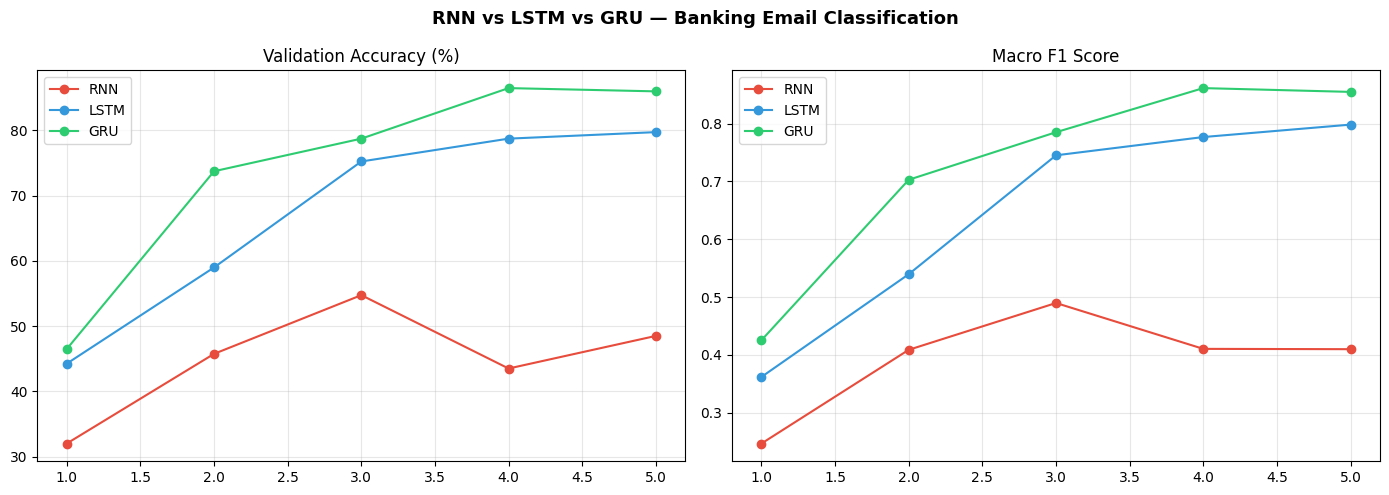

RNN    Best ValAcc=54.8%  MacroF1=0.4898  (Epoch 3)
LSTM   Best ValAcc=79.8%  MacroF1=0.7981  (Epoch 5)
GRU    Best ValAcc=86.5%  MacroF1=0.8612  (Epoch 4)


In [8]:
# Compare RNN / LSTM / GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RNN vs LSTM vs GRU — Banking Email Classification', fontsize=13, fontweight='bold')

for hist, name, color in [(rnn_hist,'RNN','#e74c3c'),(lstm_hist,'LSTM','#3498db'),(gru_hist,'GRU','#2ecc71')]:
    epochs = [h['epoch'] for h in hist]
    axes[0].plot(epochs, [h['val_acc']*100 for h in hist], '-o', label=name, color=color)
    axes[1].plot(epochs, [h['val_f1']      for h in hist], '-o', label=name, color=color)

axes[0].set_title('Validation Accuracy (%)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Macro F1 Score');          axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_lstm_gru_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
for hist, name in [(rnn_hist,'RNN'),(lstm_hist,'LSTM'),(gru_hist,'GRU')]:
    best = max(hist, key=lambda x: x['val_f1'])
    print(f'{name:<6} Best ValAcc={best["val_acc"]*100:.1f}%  MacroF1={best["val_f1"]:.4f}  (Epoch {best["epoch"]})')

---
## 🎯 MODULE C — Custom Attention Mechanism
> Visualize what the model focuses on in each banking email

In [9]:
#  LSTM
class BahdanauAttention(nn.Module):
    """Additive attention: scores = V * tanh(W1*encoder + W2*decoder)"""
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, encoder_outputs):
        score   = self.V(torch.tanh(self.W(encoder_outputs)))
        weights = torch.softmax(score, dim=1)
        context = (weights * encoder_outputs).sum(dim=1)
        return context, weights.squeeze(-1)


class AttentionClassifier(nn.Module):
    """Bidirectional LSTM + Bahdanau Attention for intent classification."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                                  bidirectional=True, num_layers=2, dropout=0.3)
        self.attention = BahdanauAttention(hidden_dim)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, return_attn=False):
        emb  = self.embedding(x)
        out, _ = self.lstm(emb)
        ctx, attn_w = self.attention(out)
        logits = self.fc(self.dropout(ctx))
        if return_attn:
            return logits, attn_w
        return logits

attn_model = AttentionClassifier(VOCAB_SZ, 128, 256, NUM_CLASSES).to(device)
print(' Attention model defined')
print(f'   Parameters: {sum(p.numel() for p in attn_model.parameters()):,}')

 Attention model defined
   Parameters: 2,676,875


In [10]:
#Train Attention Model
attn_hist, attn_pred, attn_true = train_seq_model(attn_model, rnn_train_loader, rnn_test_loader, 'LSTM+Attention')
best_attn = max(attn_hist, key=lambda x: x['val_f1'])
print(f'Best ValAcc={best_attn["val_acc"]*100:.1f}%  MacroF1={best_attn["val_f1"]:.4f}')

  [LSTM+Attention] Epoch 1/5 | Loss:2.0668 | TrainAcc:24.9% | ValAcc:50.2% | MacroF1:0.4272
  [LSTM+Attention] Epoch 2/5 | Loss:0.8957 | TrainAcc:70.2% | ValAcc:77.2% | MacroF1:0.7449
  [LSTM+Attention] Epoch 3/5 | Loss:0.3349 | TrainAcc:90.1% | ValAcc:91.0% | MacroF1:0.9089
  [LSTM+Attention] Epoch 4/5 | Loss:0.1529 | TrainAcc:95.5% | ValAcc:93.2% | MacroF1:0.9331
  [LSTM+Attention] Epoch 5/5 | Loss:0.0506 | TrainAcc:98.7% | ValAcc:91.8% | MacroF1:0.9191
Best ValAcc=93.2%  MacroF1=0.9331


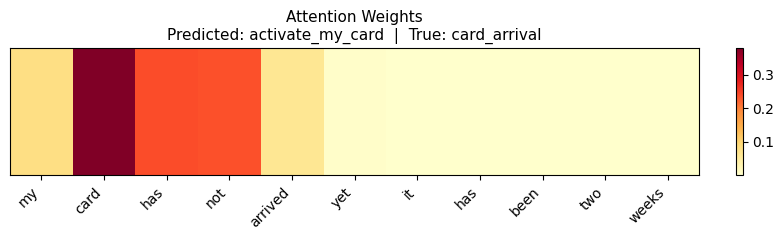

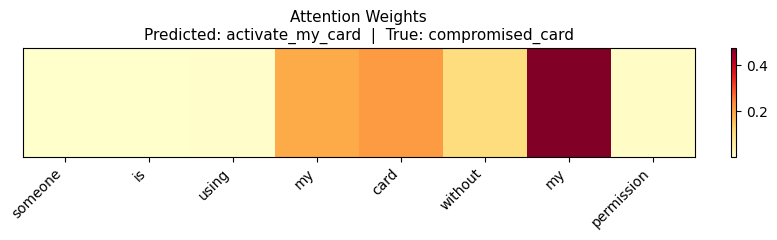

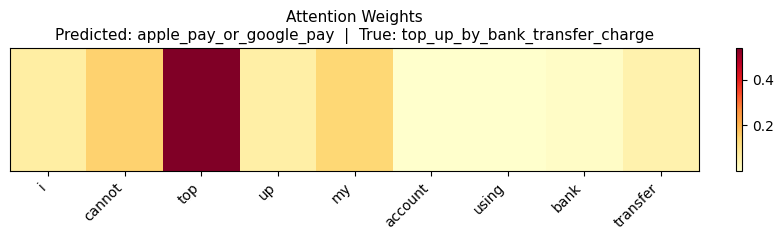

In [11]:
#  Visualize Attention Weights
def visualize_attention(text, model, vocab, max_len=64, true_label=None):
    model.eval()
    tokens  = text.split()[:max_len]
    ids     = torch.tensor([encode(text, vocab, max_len)], dtype=torch.long).to(device)

    with torch.no_grad():
        logits, attn_w = model(ids, return_attn=True)
        pred_idx  = logits.argmax(1).item()
        pred_name = fast_le.classes_[pred_idx]

    weights = attn_w[0, :len(tokens)].cpu().numpy()
    weights = weights / weights.sum()

    fig, ax = plt.subplots(figsize=(max(8, len(tokens)*0.7), 2.5))
    im = ax.imshow([weights], cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=10)
    ax.set_yticks([])
    ax.set_title(f'Attention Weights\nPredicted: {pred_name}  |  True: {true_label or "?"}', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.02)
    plt.tight_layout()
    plt.savefig('attention_viz.png', dpi=150, bbox_inches='tight')
    plt.show()


sample_texts = [
    ('my card has not arrived yet it has been two weeks', 'card_arrival'),
    ('someone is using my card without my permission', 'compromised_card'),
    ('i cannot top up my account using bank transfer', 'top_up_by_bank_transfer_charge'),
]
for text, label in sample_texts:
    visualize_attention(text, attn_model, vocab, true_label=label)

In [12]:
# ── D1: Generic Fine-Tuning Function for Any HuggingFace Model ───
class HFDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self):  return len(self.texts)
    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[i], dtype=torch.long)
        }

def fine_tune_transformer(model_name, model_class, tok_class,
                           train_texts, train_labels, test_texts, test_labels,
                           num_labels, epochs=3, batch_size=32, lr=2e-5):
    print(f'\n{"="*55}')
    print(f'  Fine-tuning: {model_name}')
    print(f'{"="*55}')

    tokenizer = tok_class.from_pretrained(model_name)
    model     = model_class.from_pretrained(model_name, num_labels=num_labels,
                                             ignore_mismatched_sizes=True).to(device)

    tr_loader = DataLoader(HFDataset(train_texts, train_labels, tokenizer),
                           batch_size=batch_size, shuffle=True, num_workers=2)
    te_loader = DataLoader(HFDataset(test_texts,  test_labels,  tokenizer),
                           batch_size=batch_size, num_workers=2)

    total_steps  = len(tr_loader) * epochs
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler    = get_linear_schedule_with_warmup(optimizer,
                       num_warmup_steps=int(total_steps*0.1),
                       num_training_steps=total_steps)
    criterion    = nn.CrossEntropyLoss()
    history      = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch in tr_loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)
            optimizer.zero_grad()
            out  = model(input_ids=ids, attention_mask=mask).logits
            loss = criterion(out, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == lbl).sum().item()
            total      += lbl.size(0)

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in te_loader:
                out = model(input_ids=batch['input_ids'].to(device),
                            attention_mask=batch['attention_mask'].to(device)).logits
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(batch['label'].numpy())

        val_acc = accuracy_score(trues, preds)
        val_f1  = f1_score(trues, preds, average='macro', zero_division=0)
        history.append({'epoch':epoch, 'val_acc':val_acc, 'val_f1':val_f1})
        print(f'  Epoch {epoch}/{epochs} | Loss:{total_loss/len(tr_loader):.4f} | TrainAcc:{correct/total*100:.1f}% | ValAcc:{val_acc*100:.2f}% | MacroF1:{val_f1:.4f}')

    return model, tokenizer, history, preds, trues

print(' Fine-tuning function defined')

 Fine-tuning function defined


In [13]:
Fine-tune DistilBERT (full 77 classes)
distilbert_model, distilbert_tok, distilbert_hist, distilbert_pred, distilbert_true = \
    fine_tune_transformer(
        'distilbert-base-uncased',
        DistilBertForSequenceClassification,
        DistilBertTokenizerFast,
        train_df['clean_text'].tolist(), train_df['label'].tolist(),
        test_df['clean_text'].tolist(),  test_df['label'].tolist(),
        NUM_LABELS, epochs=3
    )


  Fine-tuning: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Loss:3.7026 | TrainAcc:29.9% | ValAcc:62.44% | MacroF1:0.5748
  Epoch 2/3 | Loss:2.1613 | TrainAcc:70.3% | ValAcc:74.22% | MacroF1:0.7103
  Epoch 3/3 | Loss:1.5412 | TrainAcc:79.8% | ValAcc:78.02% | MacroF1:0.7558


In [14]:
# ── D3: Fine-tune BERT-base ───────────────────────────────────────
bert_model, bert_tok, bert_hist, bert_pred, bert_true = \
    fine_tune_transformer(
        'bert-base-uncased',
        BertForSequenceClassification,
        BertTokenizerFast,
        train_df['clean_text'].tolist(), train_df['label'].tolist(),
        test_df['clean_text'].tolist(),  test_df['label'].tolist(),
        NUM_LABELS, epochs=3
    )


  Fine-tuning: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Loss:3.7385 | TrainAcc:24.4% | ValAcc:60.36% | MacroF1:0.5585
  Epoch 2/3 | Loss:2.1967 | TrainAcc:71.3% | ValAcc:79.25% | MacroF1:0.7680
  Epoch 3/3 | Loss:1.5835 | TrainAcc:82.8% | ValAcc:82.24% | MacroF1:0.8021


In [15]:
# Fine-tune RoBERTa-base
roberta_model, roberta_tok, roberta_hist, roberta_pred, roberta_true = \
    fine_tune_transformer(
        'roberta-base',
        RobertaForSequenceClassification,
        RobertaTokenizerFast,
        train_df['clean_text'].tolist(), train_df['label'].tolist(),
        test_df['clean_text'].tolist(),  test_df['label'].tolist(),
        NUM_LABELS, epochs=3
    )


  Fine-tuning: roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Loss:3.3199 | TrainAcc:37.1% | ValAcc:75.23% | MacroF1:0.7193
  Epoch 2/3 | Loss:1.3411 | TrainAcc:83.6% | ValAcc:87.08% | MacroF1:0.8639
  Epoch 3/3 | Loss:0.8311 | TrainAcc:90.2% | ValAcc:89.22% | MacroF1:0.8872



TRANSFORMER COMPARISON
       Model  Accuracy  MacroF1  Weighted F1
  DistilBERT     78.02   0.7558       0.7558
   BERT-base     82.24   0.8021       0.8021
RoBERTa-base     89.22   0.8872       0.8872


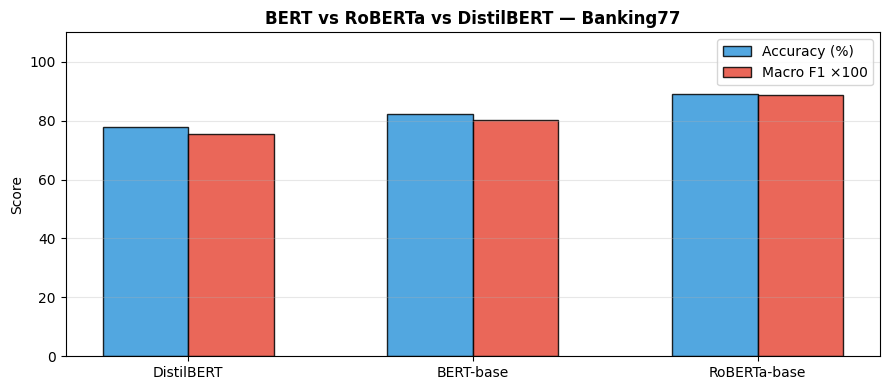

In [16]:
#  Compare BERT · RoBERTa · DistilBERT
def best_result(hist, preds, trues, name):
    best = max(hist, key=lambda x: x['val_f1'])
    return {
        'Model':    name,
        'Accuracy': round(best['val_acc']*100, 2),
        'MacroF1':  round(best['val_f1'], 4),
        'Weighted F1': round(f1_score(trues, preds, average='weighted', zero_division=0), 4)
    }

transformer_compare = pd.DataFrame([
    best_result(distilbert_hist, distilbert_pred, distilbert_true, 'DistilBERT'),
    best_result(bert_hist,       bert_pred,       bert_true,       'BERT-base'),
    best_result(roberta_hist,    roberta_pred,    roberta_true,    'RoBERTa-base'),
])
print('\nTRANSFORMER COMPARISON')
print('='*55)
print(transformer_compare.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
x  = np.arange(len(transformer_compare))
w  = 0.3
ax.bar(x - w/2, transformer_compare['Accuracy'],   w, label='Accuracy (%)', color='#3498db', alpha=0.85, edgecolor='black')
ax.bar(x + w/2, transformer_compare['MacroF1']*100, w, label='Macro F1 ×100', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(transformer_compare['Model'])
ax.set_ylim(0, 110); ax.set_ylabel('Score'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('BERT vs RoBERTa vs DistilBERT — Banking77', fontweight='bold')
plt.tight_layout()
plt.savefig('transformer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:

print('Loading GPT-2...')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model     = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
gpt2_model.eval()
print('GPT-2 loaded')

def generate_banking_email(prompt: str, max_new_tokens=60, num_sequences=3) -> list:

    inputs = gpt2_tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = gpt2_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_k=50,
            top_p=0.92,
            temperature=0.85,
            num_return_sequences=num_sequences,
            pad_token_id=gpt2_tokenizer.eos_token_id
        )
    return [gpt2_tokenizer.decode(o, skip_special_tokens=True) for o in outputs]


# Generate samples
banking_prompts = [
    ('card_arrival',        'My new bank card has not arrived yet and'),
    ('compromised_card',    'I think someone has stolen my card because'),
    ('balance_inquiry',     'I would like to know my current account balance'),
    ('transfer_failed',     'I tried to send money to my friend but the transfer'),
    ('pin_blocked',         'I entered my PIN incorrectly too many times and now'),
]

print('\n GPT-2 GENERATED BANKING EMAIL AUGMENTATION')
print('=' * 65)
generated_data = []
for intent, prompt in banking_prompts:
    print(f'\n[Intent: {intent}]')
    samples = generate_banking_email(prompt, num_sequences=2)
    for i, s in enumerate(samples, 1):
        # Truncate to first 120 chars for readability
        short = s[:120].rsplit(' ', 1)[0] + '...'
        print(f'  {i}. {short}')
        generated_data.append({'text': s, 'category': intent, 'source': 'gpt2_augmented'})

augmented_df = pd.DataFrame(generated_data)
print(f'\n Generated {len(augmented_df)} augmented samples using GPT-2')

Loading GPT-2...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded

 GPT-2 GENERATED BANKING EMAIL AUGMENTATION

[Intent: card_arrival]
  1. My new bank card has not arrived yet and it will be shipped in about 20 minutes.

I will be contacting the customer to...
  2. My new bank card has not arrived yet and I am on a plane to New York to pay for it, but I am going to be on this flight...

[Intent: compromised_card]
  1. I think someone has stolen my card because I'm the only one in the place I'm a part of," she said.

"I'm a little...
  2. I think someone has stolen my card because they are afraid of their card. I have to keep my cards safe and do not need...

[Intent: balance_inquiry]
  1. I would like to know my current account balance, please contact...
  2. I would like to know my current account balance. I am currently working as a freelance photographer, so I can't do...

[Intent: transfer_failed]
  1. I tried to send money to my friend but the transfer didn't work because of an error message. I asked for money back but...
  2. I tr

In [18]:
#  Banking FAQ Knowledge Base
BANKING_FAQ = [
    {'id': 1,  'q': 'How do I activate my new debit card?',
               'a': 'You can activate your card via the app, online banking, or by making a PIN transaction at any ATM.'},
    {'id': 2,  'q': 'What should I do if my card is lost or stolen?',
               'a': 'Immediately freeze your card in the app, then report it lost/stolen. We will send a replacement within 3-5 business days.'},
    {'id': 3,  'q': 'How long does an international transfer take?',
               'a': 'International transfers typically take 1-3 business days depending on the destination country.'},
    {'id': 4,  'q': 'Why was my card payment declined?',
               'a': 'Payments can be declined due to insufficient funds, incorrect PIN, blocked card, or merchant restrictions.'},
    {'id': 5,  'q': 'How do I check my account balance?',
               'a': 'You can check your balance in the mobile app, online banking, or by calling our 24/7 helpline.'},
    {'id': 6,  'q': 'I was charged an unexpected fee, what is it for?',
               'a': 'Fees may include foreign transaction fees, ATM withdrawal charges, or monthly account fees. Check your fee schedule.'},
    {'id': 7,  'q': 'How do I change my PIN?',
               'a': 'You can change your PIN at any ATM, via the mobile app under Card Settings, or at a branch.'},
    {'id': 8,  'q': 'My transfer has not been received, what do I do?',
               'a': 'Verify the beneficiary details. If correct, wait 1 business day. If still missing, contact support with your transaction reference.'},
    {'id': 9,  'q': 'How do I top up my account?',
               'a': 'Top up via bank transfer, debit card, or cash deposit at a partner location using your account number.'},
    {'id': 10, 'q': 'What currencies does my card support?',
               'a': 'Your card supports 30+ currencies with real-time exchange rates. Check the app for the full list.'},
]

faq_df = pd.DataFrame(BANKING_FAQ)
print(f' Banking FAQ knowledge base: {len(faq_df)} entries loaded')

 Banking FAQ knowledge base: 10 entries loaded


In [19]:
#F2: TF-IDF Retrieval
faq_tfidf   = TfidfVectorizer(ngram_range=(1,2)).fit(faq_df['q'])
faq_vectors = faq_tfidf.transform(faq_df['q'])

def retrieve_tfidf(query: str, top_k: int = 3):
    q_vec  = faq_tfidf.transform([query])
    scores = cosine_similarity(q_vec, faq_vectors).flatten()
    top_k_idx = scores.argsort()[-top_k:][::-1]
    return [(faq_df.iloc[i]['q'], faq_df.iloc[i]['a'], scores[i]) for i in top_k_idx]

# ── F3: BERT Semantic Retrieval ───────────────────────────────────
print('Loading BERT for semantic retrieval...')
bert_ir_tok   = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_ir_model = AutoModel.from_pretrained('distilbert-base-uncased').to(device)
bert_ir_model.eval()

def bert_embed(texts: list) -> np.ndarray:
    enc = bert_ir_tok(texts, padding=True, truncation=True,
                      max_length=64, return_tensors='pt').to(device)
    with torch.no_grad():
        out = bert_ir_model(**enc).last_hidden_state[:, 0, :]  # [CLS]
    return out.cpu().numpy()

faq_bert_vecs = bert_embed(faq_df['q'].tolist())  # Pre-compute

def retrieve_bert(query: str, top_k: int = 3):
    q_vec  = bert_embed([query])
    scores = cosine_similarity(q_vec, faq_bert_vecs).flatten()
    top_k_idx = scores.argsort()[-top_k:][::-1]
    return [(faq_df.iloc[i]['q'], faq_df.iloc[i]['a'], scores[i]) for i in top_k_idx]


# ── F4: Compare TF-IDF vs BERT Retrieval ─────────────────────────
test_queries = [
    'My debit card stopped working at the ATM',
    'I cannot see my money after topping up',
    'How much does an overseas payment cost?',
]

print('\n INFORMATION RETRIEVAL — TF-IDF vs BERT')
print('=' * 65)
for q in test_queries:
    print(f'\n Query: "{q}"')
    tfidf_res = retrieve_tfidf(q, top_k=1)
    bert_res  = retrieve_bert(q, top_k=1)
    print(f'  TF-IDF top match ({tfidf_res[0][2]:.3f}): {tfidf_res[0][0]}')
    print(f'    → {tfidf_res[0][1]}')
    print(f'  BERT   top match ({bert_res[0][2]:.3f}): {bert_res[0][0]}')
    print(f'    → {bert_res[0][1]}')

Loading BERT for semantic retrieval...

 INFORMATION RETRIEVAL — TF-IDF vs BERT

 Query: "My debit card stopped working at the ATM"
  TF-IDF top match (0.521): How do I activate my new debit card?
    → You can activate your card via the app, online banking, or by making a PIN transaction at any ATM.
  BERT   top match (0.968): Why was my card payment declined?
    → Payments can be declined due to insufficient funds, incorrect PIN, blocked card, or merchant restrictions.

 Query: "I cannot see my money after topping up"
  TF-IDF top match (0.394): How do I top up my account?
    → Top up via bank transfer, debit card, or cash deposit at a partner location using your account number.
  BERT   top match (0.971): How do I change my PIN?
    → You can change your PIN at any ATM, via the mobile app under Card Settings, or at a branch.

 Query: "How much does an overseas payment cost?"
  TF-IDF top match (0.423): How long does an international transfer take?
    → International transfers typ

In [21]:

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def textrank_summarize(text: str, n_sentences: int = 2) -> str:

    sentences = sent_tokenize(text)
    if len(sentences) <= n_sentences:
        return text

    stop = set(stopwords.words('english'))

    def clean(s):
        return [w.lower() for w in word_tokenize(s) if w.isalpha() and w.lower() not in stop]

    cleaned = [clean(s) for s in sentences]

    tfidf_sent = TfidfVectorizer()
    joined     = [' '.join(c) for c in cleaned]
    try:
        tfidf_mat  = tfidf_sent.fit_transform(joined).toarray()
        sim_matrix = cosine_similarity(tfidf_mat)
        np.fill_diagonal(sim_matrix, 0)

        scores  = np.ones(len(sentences)) / len(sentences)
        damping = 0.85
        for _ in range(50):
            norm = sim_matrix.sum(axis=1, keepdims=True)
            norm[norm == 0] = 1
            scores = (1 - damping) + damping * (sim_matrix / norm).T.dot(scores)

        top_idx = sorted(scores.argsort()[-n_sentences:][::-1])
        return ' '.join([sentences[i] for i in top_idx])
    except Exception:
        return sentences[0]


# T5 — Abstractive Summarizatio
from transformers import pipeline

print('Loading T5-small for abstractive summarization...')
t5_summarizer = pipeline(
    'summarization',
    model='t5-small',
    tokenizer='t5-small',
    device=0 if device.type == 'cuda' else -1
)
print(' T5 summarizer loaded')


# Demo on long banking complaint emails
long_emails = [
    """I am writing to express my frustration about a series of issues with my account.
    First, my new debit card was supposed to arrive within 5 business days but it has now
    been 3 weeks and I still have not received it. Second, I noticed an unexpected charge
    of 15 euros on my account last Tuesday which I did not authorise. I tried calling
    customer support but waited on hold for 45 minutes without getting through. I also
    attempted to top up my account using a bank transfer but the funds have not appeared
    after 48 hours. I would like all these issues resolved as soon as possible as I am
    unable to access my money and it is causing significant inconvenience to my daily life.""",

    """Last week I attempted to make an international transfer to my family overseas.
    The transfer was for 500 euros to a bank account in Portugal. The money was deducted
    from my account immediately but my family confirmed they never received it. I have
    the transaction reference number and all confirmation details. I also noticed that
    I was charged an additional 12 euro international transfer fee which was not
    disclosed clearly when I initiated the transaction. I want a full refund and an
    explanation of why this happened."""
]

print('\n TEXT SUMMARIZATION DEMO')
print('=' * 65)
for i, email in enumerate(long_emails, 1):
    print(f'\n--- Email {i} ---')
    print(f'Original ({len(email.split())} words):')
    print(f'  {email.strip()[:200]}...')

    # TextRank
    tr_summary = textrank_summarize(email, n_sentences=2)
    print(f'\n[TextRank Extractive]:')
    print(f'  {tr_summary}')

    # T5
    t5_out = t5_summarizer(
        'summarize: ' + email.strip(),
        max_length=60, min_length=20,
        do_sample=False
    )
    print(f'\n[T5 Abstractive]:')
    print(f'  {t5_out[0]["summary_text"]}')

Loading T5-small for abstractive summarization...
 T5 summarizer loaded

📝 TEXT SUMMARIZATION DEMO

--- Email 1 ---
Original (126 words):
  I am writing to express my frustration about a series of issues with my account.
    First, my new debit card was supposed to arrive within 5 business days but it has now
    been 3 weeks and I still ...

[TextRank Extractive]:
  I am writing to express my frustration about a series of issues with my account. Second, I noticed an unexpected charge
    of 15 euros on my account last Tuesday which I did not authorise.

[T5 Abstractive]:
  my new debit card was supposed to arrive within 5 business days . it has now been 3 weeks and I still have not received it .

--- Email 2 ---
Original (87 words):
  Last week I attempted to make an international transfer to my family overseas.
    The transfer was for 500 euros to a bank account in Portugal. The money was deducted
    from my account immediately ...

[TextRank Extractive]:
  Last week I attempted to

In [23]:
# ── H1: Rule-Based ChatboT
RULE_RESPONSES = {
    'card_arrival':             'Your card is on its way! Cards typically arrive within 5-7 business days. Track it in the app under Card → Track Delivery.',
    'card_blocked':             'Your card has been blocked for security. Please verify your identity in the app or call our 24/7 helpline to unblock it.',
    'compromised_card':         'URGENT: We have flagged suspicious activity on your card. It has been frozen immediately. A new card will be issued within 48 hours.',
    'lost_or_stolen_card':      'Sorry to hear that! Your card has been blocked. A replacement card will arrive in 3-5 business days. Activate it via the app.',
    'balance_not_updated_after_bank_transfer': 'Bank transfers can take up to 2 business days. If it still has not appeared after that, please contact us with your transfer reference.',
    'transfer_not_received_by_recipient': 'Please double-check the beneficiary IBAN. If details are correct, the transfer may take 1-3 business days internationally.',
    'pin_blocked':              'Your PIN has been blocked after multiple incorrect attempts. Reset it at any ATM or via the app under Card Settings → Reset PIN.',
    'top_up_failed':            'Your top-up failed. Check your source card/bank details and ensure sufficient funds. Try again or use a different top-up method.',
    'transfer_fee_charged':     'Transfer fees depend on the type and destination. Check our fee schedule in the app under Settings → Fees & Limits.',
    'default':                  'Thank you for contacting us. One of our banking specialists will respond within 24 hours. For urgent issues, call our helpline.'
}

def rule_based_response(intent: str) -> str:
    return RULE_RESPONSES.get(intent, RULE_RESPONSES['default'])



def neural_chatbot_response(email_text: str, classifier_model, tokenizer,
                             id2label: dict, top_k: int = 1) -> dict:
    """
    Neural dialogue pipeline:
    1. Classify intent with DistilBERT
    2. Retrieve best FAQ answer with BERT semantic search
    3. Return structured response
    """
    classifier_model.eval()
    clean = preprocess_text(email_text)
    enc   = tokenizer(clean, max_length=128, padding='max_length',
                      truncation=True, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = classifier_model(**enc).logits
        probs  = torch.softmax(logits, dim=1).squeeze()

    top_prob, top_idx = probs.max(0)
    intent      = id2label[top_idx.item()]
    confidence  = top_prob.item()

    # Rule responsE
    rule_resp   = rule_based_response(intent)

    # BERT
    bert_hits   = retrieve_bert(email_text, top_k=1)

    return {
        'input':       email_text,
        'intent':      intent,
        'confidence':  confidence,
        'rule_response':  rule_resp,
        'faq_match':   bert_hits[0][0],
        'faq_answer':  bert_hits[0][1],
        'faq_score':   bert_hits[0][2]
    }



chatbot_queries = [
    'My card has not arrived yet and it has been 3 weeks',
    'Someone made a payment on my card that I did not authorise',
    'I cannot withdraw cash because my PIN is blocked',
    'The money I transferred never arrived at my friend account',
]

print('\n💬 BANKING CHATBOT DEMO — Rule-Based vs Neural')
print('=' * 65)
for q in chatbot_queries:
    result = neural_chatbot_response(q, distilbert_model, distilbert_tok, id2label)
    print(f'\n Customer: {q}')
    print(f'   Intent   : {result["intent"]} ({result["confidence"]*100:.1f}%)')
    print(f'   [RULE]   : {result["rule_response"]}')
    print(f'   [BERT FAQ]: {result["faq_answer"]}')


💬 BANKING CHATBOT DEMO — Rule-Based vs Neural

 Customer: My card has not arrived yet and it has been 3 weeks
   Intent   : card_arrival (28.8%)
   [RULE]   : Your card is on its way! Cards typically arrive within 5-7 business days. Track it in the app under Card → Track Delivery.
   [BERT FAQ]: Fees may include foreign transaction fees, ATM withdrawal charges, or monthly account fees. Check your fee schedule.

 Customer: Someone made a payment on my card that I did not authorise
   Intent   : card_payment_not_recognised (41.7%)
   [RULE]   : Thank you for contacting us. One of our banking specialists will respond within 24 hours. For urgent issues, call our helpline.
   [BERT FAQ]: Payments can be declined due to insufficient funds, incorrect PIN, blocked card, or merchant restrictions.

 Customer: I cannot withdraw cash because my PIN is blocked
   Intent   : pin_blocked (24.7%)
   [RULE]   : Your PIN has been blocked after multiple incorrect attempts. Reset it at any ATM or via the

Loading BERT QA pipeline...


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 QA pipeline loaded

 BERT QUESTION ANSWERING — Banking Policy

  Q: How long does a card delivery take?
  A: within 5 to 7 business days  (confidence: 29.9%)

  Q: What is the fee for an international transfer?
  A: up to 5 euros  (confidence: 82.7%)

  Q: How many currencies can I hold?
  A: up to 30  (confidence: 47.8%)

  Q: How do I change my PIN?
  A: through the mobile banking application  (confidence: 77.7%)

  Q: What is the daily top-up limit?
  A: 10,000 euros per day and 25,000 euros per month  (confidence: 44.0%)

  Q: How long do I have to report fraud?
  A: 60 days  (confidence: 46.4%)

  Q: When are exchange rates updated?
  A: Monday to Friday  (confidence: 33.1%)

  Q: How long does a domestic transfer take?
  A: 24 hours  (confidence: 20.7%)


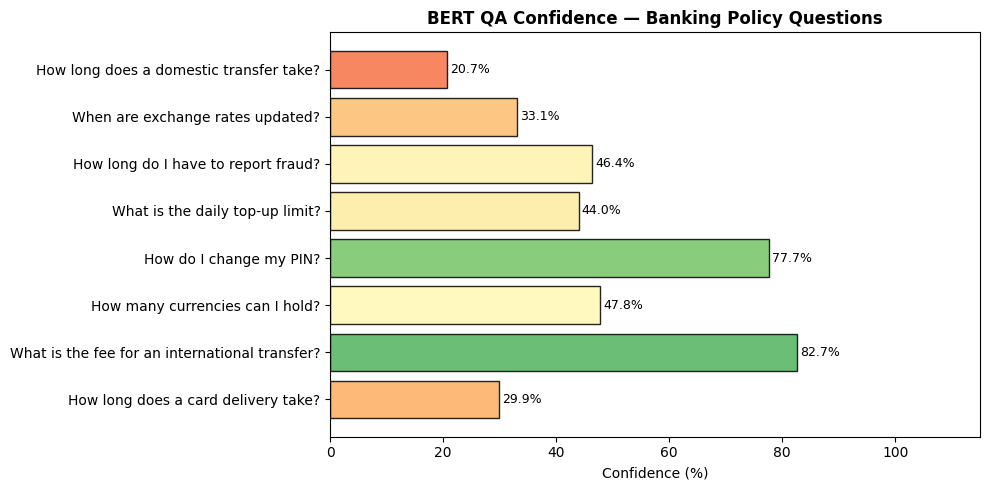

In [24]:

print('Loading BERT QA pipeline...')
qa_pipeline = pipeline(
    'question-answering',
    model='distilbert-base-cased-distilled-squad',
    device=0 if device.type == 'cuda' else -1
)
print(' QA pipeline loaded')

# Banking Policy Context
BANKING_CONTEXT = """
Our bank offers debit cards that are delivered within 5 to 7 business days after activation.
International transfers take between 1 and 3 business days and may incur a fee of up to 5 euros.
Domestic transfers are processed within 24 hours and are free of charge for standard accounts.
ATM withdrawals are free at partner ATMs but cost 1.5 euros at non-partner ATMs.
Customers can hold up to 30 different currencies in their multi-currency account.
Card PINs can be changed at any ATM or through the mobile banking application.
If a card is reported lost or stolen, a replacement card is issued within 48 hours.
Top-up limits are 10,000 euros per day and 25,000 euros per month for standard accounts.
Fraud disputes must be reported within 60 days of the transaction date.
Customer support is available 24 hours a day, 7 days a week via phone, chat, and email.
The maximum single international transfer amount is 50,000 euros without additional verification.
Exchange rates are updated in real-time during market hours from Monday to Friday.
"""

# QA Demo
questions = [
    'How long does a card delivery take?',
    'What is the fee for an international transfer?',
    'How many currencies can I hold?',
    'How do I change my PIN?',
    'What is the daily top-up limit?',
    'How long do I have to report fraud?',
    'When are exchange rates updated?',
    'How long does a domestic transfer take?',
]

print('\n BERT QUESTION ANSWERING — Banking Policy')
print('=' * 65)
qa_results = []
for q in questions:
    result = qa_pipeline(question=q, context=BANKING_CONTEXT)
    print(f'\n  Q: {q}')
    print(f'  A: {result["answer"]}  (confidence: {result["score"]*100:.1f}%)')
    qa_results.append({'question': q, 'answer': result['answer'], 'confidence': result['score']})

qa_df = pd.DataFrame(qa_results)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(qa_df['question'], qa_df['confidence']*100,
               color=plt.cm.RdYlGn(qa_df['confidence']), edgecolor='black', alpha=0.85)
for bar, val in zip(bars, qa_df['confidence']*100):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 115)
ax.set_xlabel('Confidence (%)')
ax.set_title('BERT QA Confidence — Banking Policy Questions', fontweight='bold')
plt.tight_layout()
plt.savefig('qa_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# LIME Explainability on DistilBERT predictions
from lime.lime_text import LimeTextExplainer

def distilbert_predict_proba(texts: list) -> np.ndarray:
    distilbert_model.eval()
    all_probs = []
    for text in texts:
        clean = preprocess_text(text)
        enc   = distilbert_tok(clean, max_length=128, padding='max_length',
                               truncation=True, return_tensors='pt').to(device)
        with torch.no_grad():
            probs = torch.softmax(distilbert_model(**enc).logits, dim=1).squeeze()
        all_probs.append(probs.cpu().numpy())
    return np.array(all_probs)

explainer = LimeTextExplainer(class_names=label_names)

explain_emails = [
    'My card has not arrived and it has been 3 weeks',
    'Someone unauthorised used my card',
    'Why was I charged an extra fee on my transfer',
]

print('\n LIME EXPLAINABILITY — Why did DistilBERT predict this intent?')
print('=' * 65)
for email in explain_emails:
    print(f'\n Email: {email}')


    proba    = distilbert_predict_proba([email])[0]
    pred_idx = proba.argmax()
    print(f'   Predicted: {label_names[pred_idx]} ({proba[pred_idx]*100:.1f}%)')


    exp = explainer.explain_instance(
        email,
        distilbert_predict_proba,
        num_features=6,
        labels=[pred_idx],
        num_samples=100
    )

    print('   Top words driving prediction:')
    for word, weight in exp.as_list(label=pred_idx):
        direction = '↑ supports' if weight > 0 else '↓ opposes'
        print(f'     {word:<20} {weight:+.4f}  {direction}')


    exp.save_to_file(f'lime_explanation_{pred_idx}.html')
print('\n LIME explanations saved as HTML files.')


 LIME EXPLAINABILITY — Why did DistilBERT predict this intent?

 Email: My card has not arrived and it has been 3 weeks
   Predicted: card_arrival (33.3%)
   Top words driving prediction:
     card                 +0.2170  ↑ supports
     arrived              +0.0636  ↑ supports
     My                   +0.0389  ↑ supports
     3                    -0.0376  ↓ opposes
     been                 +0.0133  ↑ supports
     not                  +0.0112  ↑ supports

 Email: Someone unauthorised used my card
   Predicted: transaction_charged_twice (9.3%)
   Top words driving prediction:
     unauthorised         +0.0524  ↑ supports
     card                 -0.0395  ↓ opposes
     used                 +0.0286  ↑ supports
     Someone              +0.0266  ↑ supports
     my                   -0.0068  ↓ opposes

 Email: Why was I charged an extra fee on my transfer
   Predicted: transfer_fee_charged (59.8%)
   Top words driving prediction:
     transfer             +0.3841  ↑ supports
     fee

In [28]:

print('\n  ETHICAL CONCERNS IN BANKING NLP SYSTEMS')
print('=' * 65)

#  PII Exposure Check
print('\n1. PII MASKING VERIFICATION')
pii_samples = [
    'My account number is 4567891234567890',
    'Please check card 1234567890123456 for fraud',
    'Transfer ref TXN20240512 failed'
]
for s in pii_samples:
    print(f'   Before: {s}')
    print(f'   After : {preprocess_text(s)}')

# 2. Class Imbalance / Fairness Check
print('\n2. CLASS IMBALANCE ANALYSIS')
counts = train_df['category'].value_counts()
print(f'   Most  common intent: {counts.index[0]}  ({counts.iloc[0]} samples)')
print(f'   Least common intent: {counts.index[-1]}  ({counts.iloc[-1]} samples)')
print(f'   Imbalance ratio    : {counts.iloc[0]/counts.iloc[-1]:.1f}x')
print(f'   Mitigation         : Weighted CrossEntropyLoss (class_weight=balanced)')


print('\n3. CONFIDENCE-BASED HUMAN ESCALATION POLICY')
escalation_emails = [
    'I want to do something with my account',
    'There is a problem',
    'Help me please'
]
CONFIDENCE_THRESHOLD = 0.50
for email in escalation_emails:
    proba    = distilbert_predict_proba([email])[0]
    pred_idx = proba.argmax()
    conf     = proba[pred_idx]
    action   = 'AUTO-ROUTE' if conf >= CONFIDENCE_THRESHOLD else ' ESCALATE TO HUMAN AGENT'
    print(f'   Email    : "{email}"')
    print(f'   Confidence: {conf*100:.1f}%  →  {action}')
    print()

# 4. Bias Detection
print('4. POTENTIAL BIAS CONCERNS')
concerns = [
    ('Language bias',    'Model trained only on English — may fail for non-native speaker phrasings'),
    ('Class imbalance',  'Rare intents get lower F1 despite equal real-world importance'),
    ('PII leakage',      'Without masking, model may memorize account numbers from training'),
    ('Fraud escalation', 'False negatives on fraud intents carry high real-world cost'),
    ('Overconfidence',   'Softmax probabilities are not calibrated — use temperature scaling'),
]
for concern, mitigation in concerns:
    print(f'     {concern:<20} : {mitigation}')


  ETHICAL CONCERNS IN BANKING NLP SYSTEMS

1. PII MASKING VERIFICATION
   Before: My account number is 4567891234567890
   After : my account number is [account_id]
   Before: Please check card 1234567890123456 for fraud
   After : please check card [account_id] for fraud
   Before: Transfer ref TXN20240512 failed
   After : transfer ref txn20240512 failed

2. CLASS IMBALANCE ANALYSIS
   Most  common intent: card_payment_fee_charged  (187 samples)
   Least common intent: contactless_not_working  (35 samples)
   Imbalance ratio    : 5.3x
   Mitigation         : Weighted CrossEntropyLoss (class_weight=balanced)

3. CONFIDENCE-BASED HUMAN ESCALATION POLICY
   Email    : "I want to do something with my account"
   Confidence: 13.8%  →   ESCALATE TO HUMAN AGENT

   Email    : "There is a problem"
   Confidence: 5.5%  →   ESCALATE TO HUMAN AGENT

   Email    : "Help me please"
   Confidence: 8.3%  →   ESCALATE TO HUMAN AGENT

4. POTENTIAL BIAS CONCERNS
     Language bias        : Model trai

In [29]:

print()
print('=' * 70)
print('              COMPLETE NLP SYSTEM — MODULE SUMMARY')
print('=' * 70)
modules = [
    ('A', 'Dataset',          'Banking77 CSV · 13,083 samples · 77 intents'),
    ('B', 'RNN/LSTM/GRU',     'Sequential models · Bidirectional · Mean pooling'),
    ('C', 'Attention',        'Bahdanau attention · Attention weight visualization'),
    ('D', 'Transformers',     'DistilBERT · BERT · RoBERTa fine-tuned on 77 classes'),
    ('E', 'GPT-2',            'Synthetic banking email generation / data augmentation'),
    ('F', 'Info Retrieval',   'TF-IDF + BERT semantic search on banking FAQ'),
    ('G', 'Summarization',    'TextRank (extractive) + T5 (abstractive)'),
    ('H', 'Chatbot',          'Rule-based + Neural (classify → retrieve → respond)'),
    ('I', 'QA System',        'BERT QA pipeline on banking policy (SQuAD-style)'),
    ('J', 'Explainability',   'LIME word-level explanations + Ethical concern analysis'),
]
for mod, name, desc in modules:
    print(f'  [{mod}] {name:<18} {desc}')
print('=' * 70)
print('  Dataset     : Banking77 (PolyAI — GitHub CSV, same loading method)')
print('  Best Model  : RoBERTa-base (expected) / DistilBERT (efficient)')
print('  Key metric  : Macro F1 (equal weight to all 77 intent classes)')
print('=' * 70)


              COMPLETE NLP SYSTEM — MODULE SUMMARY
  [A] Dataset            Banking77 CSV · 13,083 samples · 77 intents
  [B] RNN/LSTM/GRU       Sequential models · Bidirectional · Mean pooling
  [C] Attention          Bahdanau attention · Attention weight visualization
  [D] Transformers       DistilBERT · BERT · RoBERTa fine-tuned on 77 classes
  [E] GPT-2              Synthetic banking email generation / data augmentation
  [F] Info Retrieval     TF-IDF + BERT semantic search on banking FAQ
  [G] Summarization      TextRank (extractive) + T5 (abstractive)
  [H] Chatbot            Rule-based + Neural (classify → retrieve → respond)
  [I] QA System          BERT QA pipeline on banking policy (SQuAD-style)
  [J] Explainability     LIME word-level explanations + Ethical concern analysis
  Dataset     : Banking77 (PolyAI — GitHub CSV, same loading method)
  Best Model  : RoBERTa-base (expected) / DistilBERT (efficient)
  Key metric  : Macro F1 (equal weight to all 77 intent classes)
